# 🗳️ วิเคราะห์ผลเลือกตั้ง ศรีสะเกษ เขต 1 — เปรียบเทียบ 2566 vs 2568
---
**ไฟล์ที่ต้องมีในโฟลเดอร์เดียวกัน (2026/2568):**
- `constituency_units_edited.csv`
- `constituency-ว_งห_น-validated.csv`
- `early_voting_constituency_validated.csv`
- `party_list_by_unit_validated.csv`
- `party-list-ว_งห_น-validated.csv`
- `early_voting_partylist_validated.csv`

**ไฟล์ที่ต้องมี (2023/2566):**
- `election_scores_2566.csv`
- `election_locations_66.csv`


## ⚙️ 1. Config — แก้ path ที่นี่ที่เดียว

In [1]:
# ======================================================
# แก้ path ให้ตรงกับเครื่องของคุณ
# ======================================================
DATA_DIR_2026        = "./data"                           # โฟลเดอร์ที่มีไฟล์ 2026
SCORES_2566_PATH     = "election_scores_2566.csv"    # ไฟล์คะแนนปี 2023
LOCATIONS_66_PATH    = "election_locations_66.csv"   # ไฟล์ location ปี 2023

PROVINCE_2566        = "ศรีสะเกษ"
DISTRICT_NUMBER_2566 = 1   # เขตเลือกตั้งที่ 1

# mapping พรรค 2026 → column 2566  (ก้าวไกล rebrand เป็น ประชาชน)
PARTY_MAP_PARTYLIST = {
    "เพื่อไทย"        : "บช_เพื่อไทย",
    "ภูมิใจไทย"       : "บช_ภูมิใจไทย",
    "ประชาชน"         : "บช_ก้าวไกล",
    "ประชาธิปัตย์"    : "บช_ประชาธิปัตย์",
    "รวมไทยสร้างชาติ" : "บช_รวมไทยสร้างชาติ",
    "พลังประชารัฐ"    : "บช_พลังประชารัฐ",
    "เสรีรวมไทย"      : "บช_เสรีรวมไทย",
    "ประชาชาติ"       : "บช_ประชาชาติ",
    "ไทยสร้างไทย"     : "บช_ไทยสร้างไทย",
}

# เพิ่ม manual mapping ตำบลที่ auto-match ไม่ได้ (ดูผลจาก Cell 4 แล้วค่อยเพิ่ม)
MANUAL_TAMBON_MAP = {
    # "ชื่อตำบลใน 2026" : "ชื่อตำบลใน 2566",
}


## 📦 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings("ignore")

# รองรับฟอนต์ภาษาไทยใน matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans', 'Tahoma', 'sans-serif']
plt.rcParams['figure.dpi'] = 120

print("✅ Import สำเร็จ")


✅ Import สำเร็จ


## 📂 3. โหลดข้อมูล 2026

In [4]:
CANDIDATES = [
    "นายสุเกษม เรืองนุช", "นายเนียม ผลบุญ", "นายธเนส เครือรัตน์",
    "นายวีรชัย จันทร์ดวงศรี", "นายสิริพงศ์ อังคสกุลเกียรติ",
    "นายสุรเดช นาจำปา", "นายคณีศร คำโสภา",
    "นายกุลธวัช สาลี", "นางสาวฉวี ปิ่นทอม",
]

def _load_const(path, source, tambon_col="ตำบลหน่วยเลือกตั้ง"):
    df = pd.read_csv(path).dropna(subset=[tambon_col])
    df = df.rename(columns={tambon_col: "ตำบล"})
    df["source"] = source
    num_cols = ["eligible","show_up","prepared_cards","used_cards","good_cards","bad_cards"] + CANDIDATES
    df[[c for c in num_cols if c in df.columns]] = (
        df[[c for c in num_cols if c in df.columns]].apply(pd.to_numeric, errors="coerce"))
    return df

def _load_early_const(path):
    df = pd.read_csv(path)
    df = df.rename(columns={"ชุด": "ตำบล", "received_cards": "used_cards"})
    df["eligible"] = df["show_up"] = df["prepared_cards"] = np.nan
    df["source"] = "early"
    return df

def _load_partylist(path, source):
    df = pd.read_csv(path).dropna(subset=["ตำบล"])
    df["source"] = source
    return df

def _load_early_partylist(path):
    df = pd.read_csv(path)
    df = df.rename(columns={"ชุด": "ตำบล", "received_cards": "used_cards"})
    df["eligible"] = df["show_up"] = np.nan
    df["source"] = "early"
    return df

def get_party_cols(df):
    meta = {"source_pdf","ตำบล","หน่วยเลือกตั้ง","pages_read","ชุด",
            "eligible","show_up","prepared_cards","used_cards",
            "good_cards","bad_cards","no_vote_cards","remaining_cards","source"}
    return [c for c in df.columns if c not in meta and pd.notna(c) and str(c).strip()]

d = DATA_DIR_2026
const_df = pd.concat([
    _load_const(f"{d}/constituency_units_edited.csv",         "main"),
    _load_const(f"{d}/constituency-วังหิน-validated.csv",    "wanghin"),
    _load_early_const(f"{d}/early_voting_constituency_validated.csv"),
], ignore_index=True)

party_df = pd.concat([
    _load_partylist(f"{d}/party_list_by_unit_validated.csv",  "main"),
    _load_partylist(f"{d}/party-list-วังหิน-validated.csv",  "wanghin"),
    _load_early_partylist(f"{d}/early_voting_partylist_validated.csv"),
], ignore_index=True)

p_cols = get_party_cols(party_df)
party_df[p_cols] = party_df[p_cols].apply(pd.to_numeric, errors="coerce")

print(f"✅ โหลด 2026 สำเร็จ — ส.ส. แบ่งเขต: {len(const_df)} rows | Party list: {len(party_df)} rows")


✅ โหลด 2026 สำเร็จ — ส.ส. แบ่งเขต: 296 rows | Party list: 296 rows


## 📊 4. Voter Turnout 2026

In [5]:
# ── ภาพรวมทั้งเขต ──
eligible  = const_df["eligible"].sum()
show_up   = const_df["show_up"].sum()
good      = const_df["good_cards"].sum()
bad       = const_df["bad_cards"].sum()
used      = const_df["used_cards"].sum()

print(f"ผู้มีสิทธิ์รวม   : {eligible:>10,.0f} คน")
print(f"ผู้มาใช้สิทธิ์   : {show_up:>10,.0f} คน")
print(f"Turnout          : {show_up/eligible*100:>9.2f} %")
print(f"บัตรดี           : {good:>10,.0f}")
print(f"บัตรเสีย         : {bad:>10,.0f}  ({bad/used*100:.2f}%)")


ผู้มีสิทธิ์รวม   :    131,029 คน
ผู้มาใช้สิทธิ์   :     82,104 คน
Turnout          :     62.66 %
บัตรดี           :     93,427
บัตรเสีย         :      2,318  (2.38%)


In [6]:
# ── ระดับตำบล ──
df_main = const_df[const_df["source"].isin(["main","wanghin"])]
turnout_tab = df_main.groupby("ตำบล", as_index=False).agg(
    eligible   = ("eligible",   "sum"),
    show_up    = ("show_up",    "sum"),
    good_cards = ("good_cards", "sum"),
    bad_cards  = ("bad_cards",  "sum"),
    used_cards = ("used_cards", "sum"),
)
turnout_tab["turnout_pct"]  = (turnout_tab["show_up"]  / turnout_tab["eligible"]  * 100).round(2)
turnout_tab["bad_card_pct"] = (turnout_tab["bad_cards"] / turnout_tab["used_cards"] * 100).round(2)
turnout_tab = turnout_tab.sort_values("turnout_pct", ascending=False).reset_index(drop=True)
turnout_tab


,ตำบล,eligible,show_up,good_cards,bad_cards,used_cards,turnout_pct,bad_card_pct
0,โพนข่า,4678.0,3631.0,3515.0,82.0,3631.0,77.62,2.26
1,หนองครก,5513.0,4195.0,4172.0,90.0,4312.0,76.09,2.09
2,โพนค้อ,2347.0,1742.0,1667.0,54.0,1742.0,74.22,3.10
3,หนองไผ่,5273.0,3773.0,3653.0,81.0,3773.0,71.55,2.15
4,หมากเขียบ,4006.0,2841.0,2759.0,57.0,2841.0,70.92,2.01
5,โพนเขวา,6300.0,4439.0,4282.0,119.0,4439.0,70.46,2.68
6,เทศบาลเมืองศรีสะเกษ,29890.0,20061.0,19542.0,340.0,20641.0,67.12,1.65
7,เทศบาลตำบลน้ำคำ,8549.0,5664.0,5618.0,205.0,5887.0,66.25,3.48
8,ธาตุ,5557.0,3575.0,3265.0,94.0,3375.0,64.33,2.79
9,จาน,5686.0,3604.0,3771.0,96.0,3898.0,63.38,2.46


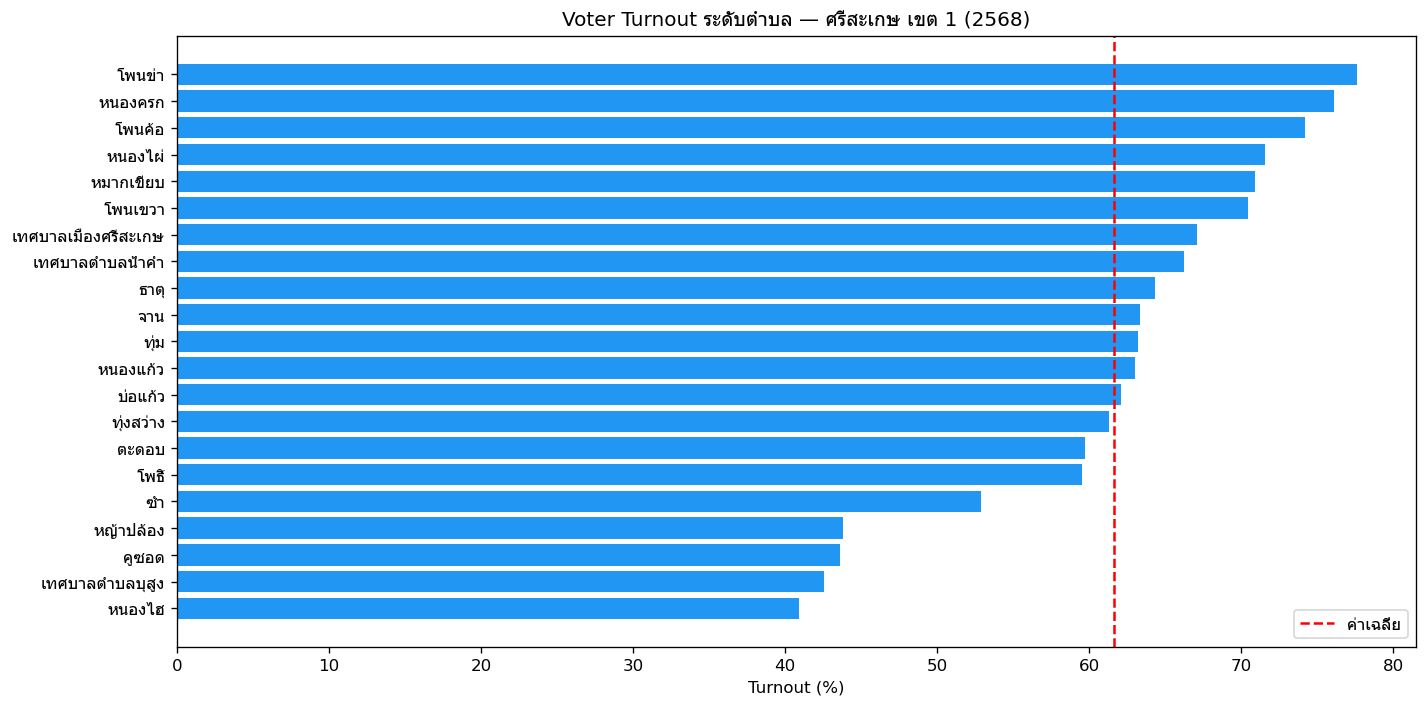

In [7]:
# ── Bar chart: Turnout ระดับตำบล ──
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(turnout_tab["ตำบล"], turnout_tab["turnout_pct"], color="#2196F3")
ax.axvline(turnout_tab["turnout_pct"].mean(), color="red", linestyle="--", label="ค่าเฉลี่ย")
ax.set_xlabel("Turnout (%)")
ax.set_title("Voter Turnout ระดับตำบล — ศรีสะเกษ เขต 1 (2568)")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 🏆 5. ผลคะแนน ส.ส. แบ่งเขต

In [8]:
# ── คะแนนรวมทั้งเขต ──
cand_totals = const_df[CANDIDATES].sum().reset_index()
cand_totals.columns = ["ผู้สมัคร", "คะแนนรวม"]
cand_totals["vote_share"] = (cand_totals["คะแนนรวม"] / cand_totals["คะแนนรวม"].sum() * 100).round(2)
cand_totals = cand_totals.sort_values("คะแนนรวม", ascending=False).reset_index(drop=True)
cand_totals


,ผู้สมัคร,คะแนนรวม,vote_share
0,นายสิริพงศ์ อังคสกุลเกียรติ,52563.0,56.26
1,นายธเนส เครือรัตน์,24938.0,26.69
2,นายสุเกษม เรืองนุช,13374.0,14.31
3,นางสาวฉวี ปิ่นทอม,851.0,0.91
4,นายวีรชัย จันทร์ดวงศรี,458.0,0.49
5,นายคณีศร คำโสภา,431.0,0.46
6,นายเนียม ผลบุญ,389.0,0.42
7,นายสุรเดช นาจำปา,219.0,0.23
8,นายกุลธวัช สาลี,209.0,0.22


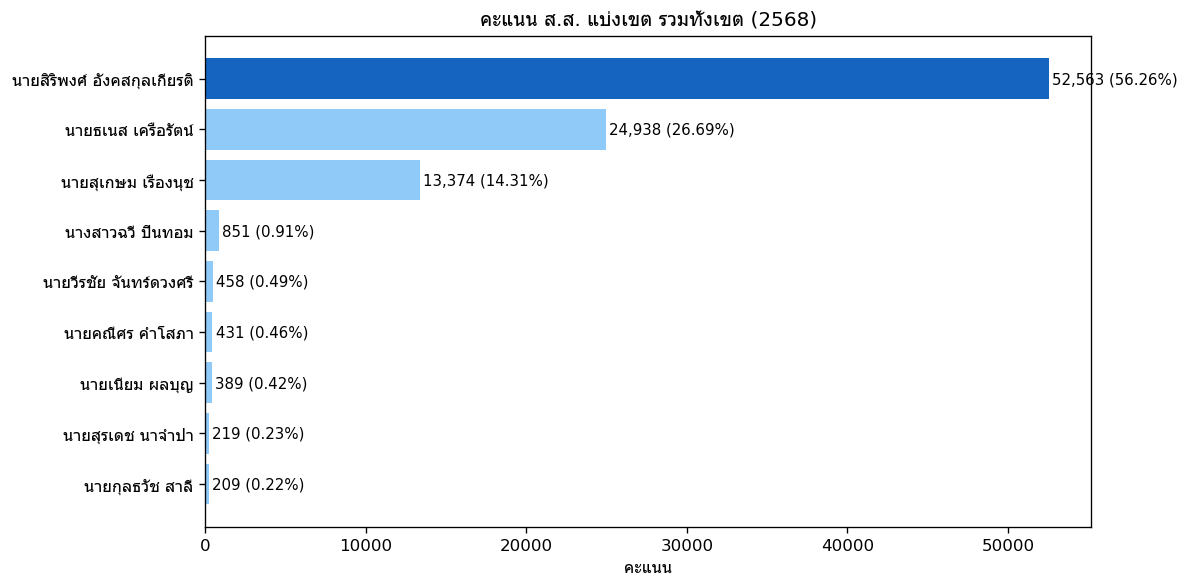

In [9]:
# ── Bar chart คะแนนผู้สมัคร ──
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#1565C0" if i == 0 else "#90CAF9" for i in range(len(cand_totals))]
ax.barh(cand_totals["ผู้สมัคร"], cand_totals["คะแนนรวม"], color=colors)
for i, (v, s) in enumerate(zip(cand_totals["คะแนนรวม"], cand_totals["vote_share"])):
    ax.text(v + 200, i, f"{v:,.0f} ({s}%)", va="center", fontsize=9)
ax.set_xlabel("คะแนน")
ax.set_title("คะแนน ส.ส. แบ่งเขต รวมทั้งเขต (2568)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [10]:
# ── ผู้ชนะระดับตำบล ──
by_tab = df_main.groupby("ตำบล")[CANDIDATES].sum()
by_tab["winner"]       = by_tab[CANDIDATES].idxmax(axis=1)
by_tab["winner_votes"] = by_tab[CANDIDATES].max(axis=1)
by_tab["total"]        = by_tab[CANDIDATES].sum(axis=1)
by_tab["winner_share"] = (by_tab["winner_votes"] / by_tab["total"] * 100).round(2)
by_tab[["winner","winner_votes","total","winner_share"]].reset_index()


,ตำบล,winner,winner_votes,total,winner_share
0,คูซอด,นายสิริพงศ์ อังคสกุลเกียรติ,1493.0,2443.0,61.11
1,จาน,นายสิริพงศ์ อังคสกุลเกียรติ,2078.0,3771.0,55.10
2,ซำ,นายสิริพงศ์ อังคสกุลเกียรติ,1930.0,3478.0,55.49
3,ตะดอบ,นายสิริพงศ์ อังคสกุลเกียรติ,1831.0,2698.0,67.87
4,ทุ่งสว่าง,นายสิริพงศ์ อังคสกุลเกียรติ,1203.0,2244.0,53.61
5,ทุ่ม,นายสิริพงศ์ อังคสกุลเกียรติ,1981.0,3689.0,53.70
6,ธาตุ,นายสิริพงศ์ อังคสกุลเกียรติ,1801.0,3267.0,55.13
7,บ่อแก้ว,นายสิริพงศ์ อังคสกุลเกียรติ,1786.0,3045.0,58.65
8,หญ้าปล้อง,นายสิริพงศ์ อังคสกุลเกียรติ,1776.0,3406.0,52.14
9,หนองครก,นายสิริพงศ์ อังคสกุลเกียรติ,2595.0,4172.0,62.20


## 🎉 6. ผลคะแนน Party List 2026

In [11]:
# ── Top 15 พรรค ──
p_totals = party_df[p_cols].sum().reset_index()
p_totals.columns = ["พรรค", "คะแนนรวม"]
p_totals["vote_share"] = (p_totals["คะแนนรวม"] / p_totals["คะแนนรวม"].sum() * 100).round(2)
p_totals = p_totals.sort_values("คะแนนรวม", ascending=False).head(15).reset_index(drop=True)
p_totals


,พรรค,คะแนนรวม,vote_share
0,ภูมิใจไทย,29193.0,31.72
1,เพื่อไทย,25548.0,27.76
2,ประชาชน,22244.0,24.17
3,รวมใจไทย,2186.0,2.38
4,เศรษฐกิจ,2116.0,2.30
5,ประชาธิปัตย์,1498.0,1.63
6,ใหม่,1100.0,1.20
7,รวมไทยสร้างชาติ,1006.0,1.09
8,เพื่อชาติไทย,983.0,1.07
9,ประชาธิปไตยใหม่,534.0,0.58


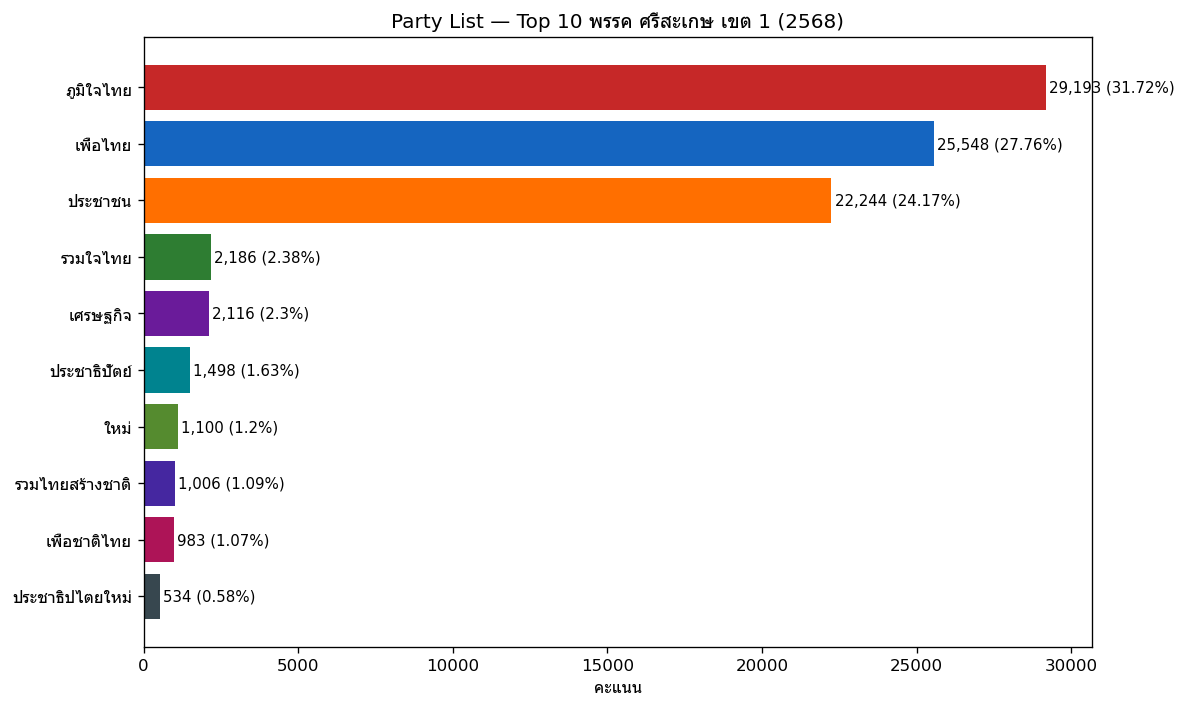

In [12]:
# ── Bar chart Party List ──
fig, ax = plt.subplots(figsize=(10, 6))
top10 = p_totals.head(10)
colors = ["#C62828","#1565C0","#FF6F00","#2E7D32","#6A1B9A",
          "#00838F","#558B2F","#4527A0","#AD1457","#37474F"]
ax.barh(top10["พรรค"], top10["คะแนนรวม"], color=colors[:len(top10)])
for i, (v, s) in enumerate(zip(top10["คะแนนรวม"], top10["vote_share"])):
    ax.text(v + 100, i, f"{v:,.0f} ({s}%)", va="center", fontsize=9)
ax.set_xlabel("คะแนน")
ax.set_title("Party List — Top 10 พรรค ศรีสะเกษ เขต 1 (2568)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 📂 7. โหลดข้อมูล 2566 (อาจใช้เวลาสักครู่)

In [14]:
print("📂 กำลังโหลด election_locations_66.csv ...")
loc = pd.read_csv(LOCATIONS_66_PATH, dtype=str)
loc.columns = loc.columns.str.strip()

loc_province = loc[loc["provincename"].str.contains(PROVINCE_2566, na=False)]
loc_district = loc_province[
    loc_province["divisionnumber"].astype(str).str.strip() == str(DISTRICT_NUMBER_2566)
].copy()
print(f"  พบ {len(loc_district)} หน่วยในไฟล์ locations")

print("📂 กำลังโหลด election_scores_2566.csv (chunk mode) ...")
valid_ids  = set(loc_district["unitid"].astype(str).str.strip())
chunk_list = []
for chunk in pd.read_csv(SCORES_2566_PATH, chunksize=50_000, dtype=str, low_memory=False):
    chunk.columns = chunk.columns.str.strip()
    id_col = "id" if "id" in chunk.columns else chunk.columns[0]
    matched = chunk[chunk[id_col].astype(str).str.strip().isin(valid_ids)]
    if not matched.empty:
        chunk_list.append(matched)

df_66 = pd.concat(chunk_list, ignore_index=True)
df_66 = df_66.merge(
    loc_district[["unitid","subdistrictname"]],
    left_on=id_col, right_on="unitid", how="left"
)
num66 = [c for c in df_66.columns if c.startswith("บช_") or c.startswith("เขต_")]
df_66[num66] = df_66[num66].apply(pd.to_numeric, errors="coerce")

print(f"✅ โหลด 2566 สำเร็จ: {len(df_66)} หน่วย")


📂 กำลังโหลด election_locations_66.csv ...
  พบ 285 หน่วยในไฟล์ locations
📂 กำลังโหลด election_scores_2566.csv (chunk mode) ...


FileNotFoundError: [Errno 2] No such file or directory: 'election_scores_2566.csv'

## 🔗 8. จับคู่ชื่อตำบล 2023 ↔ 2026

In [ ]:
def normalize_tambon(name):
    if not isinstance(name, str): return ""
    name = name.strip()
    for prefix in ["เทศบาลตำบล","เทศบาลเมือง","เทศบาลนคร","ตำบล"]:
        if name.startswith(prefix):
            name = name[len(prefix):]
            break
    return name.strip()

tambons_26 = const_df[const_df["source"].isin(["main","wanghin"])]["ตำบล"].dropna().unique().tolist()
tambons_66 = df_66["subdistrictname"].dropna().unique().tolist()
norm_66    = {normalize_tambon(t): t for t in tambons_66}

auto_map, unmatched = {}, []
for t26 in tambons_26:
    n26 = normalize_tambon(t26)
    if n26 in norm_66:
        auto_map[t26] = norm_66[n26]
    else:
        candidates = [t66 for n66, t66 in norm_66.items() if n26 in n66 or n66 in n26]
        if len(candidates) == 1:
            auto_map[t26] = candidates[0]
        else:
            unmatched.append(t26)

full_map = {**auto_map, **MANUAL_TAMBON_MAP}

print(f"✅ Match ได้ {len(full_map)} ตำบล")
if unmatched:
    print(f"⚠️  Match ไม่ได้ {len(unmatched)} ตำบล: {unmatched}")
    print("   → เพิ่ม MANUAL_TAMBON_MAP ใน Cell 1 แล้วรัน Cell นี้ใหม่")
else:
    print("✅ ทุกตำบล match สำเร็จ")

# แสดง mapping ทั้งหมด
pd.DataFrame([{"ตำบล_2026": k, "ตำบล_2566": v} for k,v in full_map.items()])


## 📈 9. Turnout Swing (2566 → 2568)

In [ ]:
# ── aggregate 2566 ระดับตำบล ──
t66 = df_66.groupby("subdistrictname").agg(
    eligible_66 = ("บช_ผู้มีสิทธิ์",   "sum"),
    show_up_66  = ("บช_ผู้มาใช้สิทธิ์","sum"),
).reset_index().rename(columns={"subdistrictname": "ตำบล_66"})
t66["turnout_66"] = (t66["show_up_66"] / t66["eligible_66"] * 100).round(2)

# ── aggregate 2026 ระดับตำบล ──
t26 = turnout_tab[["ตำบล","eligible","show_up","turnout_pct"]].rename(
    columns={"eligible":"eligible_26","show_up":"show_up_26","turnout_pct":"turnout_26"})

# ── merge ด้วย full_map ──
rows = []
for t_26, t_66 in full_map.items():
    r66 = t66[t66["ตำบล_66"] == t_66]
    r26 = t26[t26["ตำบล"]    == t_26]
    if r66.empty or r26.empty: continue
    rows.append({
        "ตำบล":         t_26,
        "eligible_66":  int(r66.iloc[0]["eligible_66"]),
        "eligible_26":  int(r26.iloc[0]["eligible_26"]),
        "turnout_66":   r66.iloc[0]["turnout_66"],
        "turnout_26":   r26.iloc[0]["turnout_26"],
        "swing":        round(r26.iloc[0]["turnout_26"] - r66.iloc[0]["turnout_66"], 2),
    })

t_swing = pd.DataFrame(rows).sort_values("swing", ascending=False).reset_index(drop=True)
t_swing


In [ ]:
# ── Diverging bar: Turnout Swing ──
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#1565C0" if v >= 0 else "#C62828" for v in t_swing["swing"]]
ax.barh(t_swing["ตำบล"], t_swing["swing"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Swing (pp)")
ax.set_title("Turnout Swing ระดับตำบล (2566 → 2568)\n(+) มาใช้สิทธิ์มากขึ้น | (-) น้อยลง")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 🔄 10. Party List Swing (2566 → 2568)

In [ ]:
# ── ระดับเขต ──
totals_66   = df_66[[c for c in df_66.columns if c.startswith("บช_")]].sum()
party_sum66 = sum(totals_66.get(col, 0) for col in PARTY_MAP_PARTYLIST.values())

totals_26    = party_df[p_cols].sum()
party_sum26  = totals_26.sum()

rows = []
for name_26, col_66 in PARTY_MAP_PARTYLIST.items():
    v66 = totals_66.get(col_66, 0)
    v26 = totals_26.get(name_26, 0)
    s66 = v66 / party_sum66 * 100 if party_sum66 else 0
    s26 = v26 / party_sum26 * 100 if party_sum26 else 0
    rows.append({
        "พรรค":       name_26,
        "votes_66":   int(v66), "votes_26": int(v26),
        "share_66":   round(s66, 2), "share_26": round(s26, 2),
        "swing":      round(s26 - s66, 2),
    })

ps_overall = pd.DataFrame(rows).sort_values("swing", ascending=False).reset_index(drop=True)
ps_overall


In [ ]:
# ── Diverging bar: Party Swing ──
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#1565C0" if v >= 0 else "#C62828" for v in ps_overall["swing"]]
bars = ax.barh(ps_overall["พรรค"], ps_overall["swing"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
for bar, row in zip(bars, ps_overall.itertuples()):
    x = row.swing + (0.3 if row.swing >= 0 else -0.3)
    ax.text(x, bar.get_y() + bar.get_height()/2,
            f"{row.swing:+.1f}pp", va="center", ha="left" if row.swing >= 0 else "right", fontsize=9)
ax.set_xlabel("Swing (percentage points)")
ax.set_title("Party List Swing ระดับเขต (2566 → 2568)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
# ── Party swing ระดับตำบล — heatmap ──
agg66 = df_66.groupby("subdistrictname")[[c for c in df_66.columns if c.startswith("บช_")]].sum().reset_index()
agg66 = agg66.rename(columns={"subdistrictname": "ตำบล_66"})

p26_main = party_df[party_df["source"].isin(["main","wanghin"])].copy()
p26_main["ตำบล"] = p26_main["ตำบล"].astype(str).str.strip()
agg26 = p26_main.groupby("ตำบล")[p_cols].sum().reset_index()

swing_rows = []
for t_26, t_66 in full_map.items():
    r66 = agg66[agg66["ตำบล_66"] == t_66]
    r26 = agg26[agg26["ตำบล"]    == t_26]
    if r66.empty or r26.empty: continue
    tot66 = sum(r66.iloc[0].get(col, 0) for col in PARTY_MAP_PARTYLIST.values())
    tot26 = r26.iloc[0][p_cols].sum()
    for name_26, col_66 in PARTY_MAP_PARTYLIST.items():
        v66 = r66.iloc[0].get(col_66, 0) if col_66 in r66.columns else 0
        v26 = r26.iloc[0].get(name_26, 0) if name_26 in r26.columns else 0
        s66 = v66 / tot66 * 100 if tot66 else 0
        s26 = v26 / tot26 * 100 if tot26 else 0
        swing_rows.append({"ตำบล": t_26, "พรรค": name_26, "swing": round(s26 - s66, 2)})

ps_tambon = pd.DataFrame(swing_rows)
pivot = ps_tambon.pivot(index="ตำบล", columns="พรรค", values="swing")

fig, ax = plt.subplots(figsize=(13, 9))
im = ax.imshow(pivot.values, cmap="RdBu", aspect="auto", vmin=-20, vmax=20)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:+.1f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(val) > 12 else "black")
plt.colorbar(im, ax=ax, label="Swing (pp)")
ax.set_title("Party List Swing ระดับตำบล (2566 → 2568)\nสีน้ำเงิน = เพิ่มขึ้น | สีแดง = ลดลง")
plt.tight_layout()
plt.show()


## 💾 11. Export ผลลัพธ์

In [ ]:
turnout_tab.to_csv("turnout_by_tambon_2026.csv",         index=False, encoding="utf-8-sig")
t_swing.to_csv("turnout_swing_by_tambon.csv",             index=False, encoding="utf-8-sig")
ps_overall.to_csv("party_swing_overall.csv",              index=False, encoding="utf-8-sig")
ps_tambon.to_csv("party_swing_by_tambon_long.csv",        index=False, encoding="utf-8-sig")
pivot.to_csv("party_swing_by_tambon_pivot.csv",                        encoding="utf-8-sig")
cand_totals.to_csv("candidate_totals_2026.csv",           index=False, encoding="utf-8-sig")

print("✅ Export เสร็จ! ไฟล์ที่ได้:")
for f in ["turnout_by_tambon_2026.csv","turnout_swing_by_tambon.csv",
          "party_swing_overall.csv","party_swing_by_tambon_long.csv",
          "party_swing_by_tambon_pivot.csv","candidate_totals_2026.csv"]:
    print(f"  → {f}")
